# Causal Forest Uplift Modeling
## Hillstrom Email Marketing Dataset

**Author:** Beza Tilahun  

We implement the Causal Forest using **CausalML** by Uber to estimate 
the Individual Treatment Effect (CATE) of the email campaign.

**Model:** `UpliftRandomForestClassifier`  
**Library:** CausalML (Uber)  
**Theory:** Rzepakowski & Jaroszewicz (2012)  
**Treatment input:** String labels ('treatment' / 'control')  
**Output:** Uplift scores per customer

In [1]:
!pip install causalml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.9 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.6 MB/s  0:00:00
  Created wheel for causalml: filename=causalml-0.17.0-cp313-cp313-macosx_12_0_arm64.whl size=2865132 sha256=7507ece7495d30bd6145921db75840a381d77474b9d5bcc6e40979026977e7d2
  Stored in directory: /Users/beza/Library/Caches/pip/wheels/39/f5/86/1ce20c63eba1929d0ebec5abbf113145c1ff0002d51da669c4
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24635 sha256=e99d18655dae95f13c493acadd08dddeadb8dccc755009a2220b0200327a8fd6
  Stored in directory: /Users/beza/Library/Caches/pip/w

In [8]:
!pip install causalml

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import os
os.chdir('/Users/beza/hillstrom-email-uplift-modeling')
print("Working directory:", os.getcwd())

Working directory: /Users/beza/hillstrom-email-uplift-modeling


In [7]:
# Load the processed data
X_train = pd.read_csv('data/processed/X_train.csv')
X_test  = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()
T_train = pd.read_csv('data/processed/treatment_train.csv').squeeze()
T_test  = pd.read_csv('data/processed/treatment_test.csv').squeeze()

# Convert to numpy
X_tr = X_train.values
X_te = X_test.values
Y_tr = y_train.values
Y_te = y_test.values
T_tr = T_train.values
T_te = T_test.values

print("X_train shape:", X_train.shape)
print("y_train value counts:\n", y_train.value_counts())
print("T_train value counts:\n", T_train.value_counts())
print(X_train.head())

X_train shape: (48000, 18)
y_train value counts:
 visit
0    40955
1     7045
Name: count, dtype: int64
T_train value counts:
 treatment_binary
1    32020
0    15980
Name: count, dtype: int64
   recency  history  mens  womens  newbie  history_segment_1) $0 - $100  \
0        9    40.52     0       1       0                           1.0   
1        8   364.01     0       1       0                           0.0   
2        5    29.99     0       1       1                           1.0   
3       10    67.09     1       0       0                           1.0   
4        3   140.68     0       1       0                           0.0   

   history_segment_2) $100 - $200  history_segment_3) $200 - $350  \
0                             0.0                             0.0   
1                             0.0                             0.0   
2                             0.0                             0.0   
3                             0.0                             0.0   
4           

## Causal Forest Model

We implement the Causal Forest using **CausalML** by Uber to estimate 
the Individual Treatment Effect (CATE) of the email campaign.

For each customer, it estimates:

$$\tau(x) = E[Y(1) - Y(0) \mid X = x]$$

Where:
- $Y(1)$ = outcome if the customer receives the email
- $Y(0)$ = outcome if the customer does NOT receive the email
- $\tau(x)$ = the **uplift score**

**Model settings:**
- 200 estimators (trees)
- Min samples per leaf: 10
- Max depth: 10
- Library: `causalml` (Uber)

In [9]:
from causalml.inference.tree import UpliftRandomForestClassifier

# CausalML requires string treatment labels
treatment_train = np.where(T_tr == 1, 'treatment', 'control')
treatment_test  = np.where(T_te == 1, 'treatment', 'control')

# Train CausalML Uplift Random Forest
print("Training CausalML Uplift Random Forest...")
cf_causal = UpliftRandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    control_name='control'
)

cf_causal.fit(X_tr, treatment=treatment_train, y=Y_tr)
print("Training complete!")

Failed to import duecredit due to No module named 'duecredit'


Training CausalML Uplift Random Forest...
Training complete!


In [10]:
# Predict uplift scores on test set
uplift_preds = cf_causal.predict(X_te)
cate_causalml = uplift_preds[:, 0]  # uplift scores for treatment group

print("Uplift score stats:")
print(f"  Mean:  {cate_causalml.mean():.4f}")
print(f"  Std:   {cate_causalml.std():.4f}")
print(f"  Min:   {cate_causalml.min():.4f}")
print(f"  Max:   {cate_causalml.max():.4f}")
print(f"  % Positive uplift: {(cate_causalml > 0).mean()*100:.1f}%")
print(f"  % Negative uplift: {(cate_causalml < 0).mean()*100:.1f}%")

Uplift score stats:
  Mean:  0.0608
  Std:   0.0377
  Min:   -0.1647
  Max:   0.2861
  % Positive uplift: 94.8%
  % Negative uplift: 5.2%


## 3. Uplift Score Distribution

After training, we predict the CATE (uplift score) for each customer 
in the test set.

**Interpretation:**
- **Positive uplift** → email increases conversion probability (Persuadables)
- **Near zero uplift** → email has no effect (Sure Things / Lost Causes)
- **Negative uplift** → email hurts conversion (Do-Not-Disturbs)

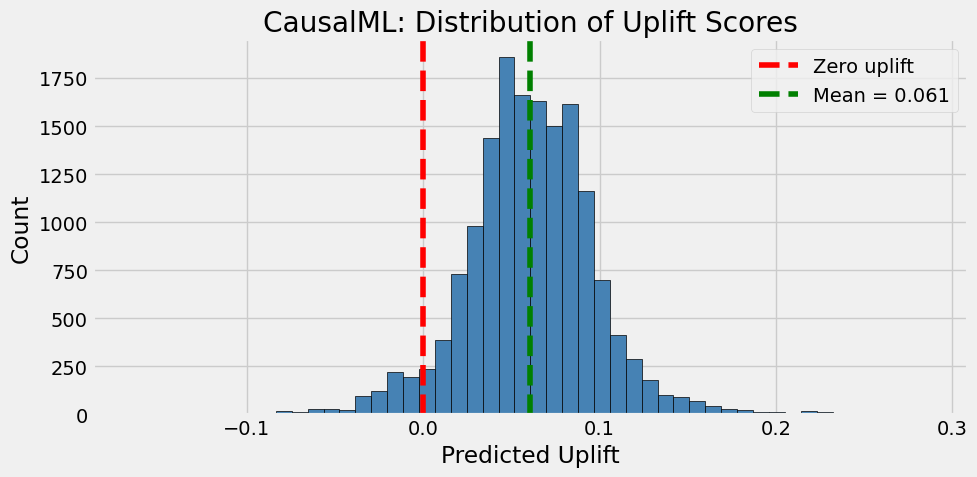

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(cate_causalml, bins=50, color='steelblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Zero uplift')
plt.axvline(x=cate_causalml.mean(), color='green', linestyle='--',
            label=f'Mean = {cate_causalml.mean():.3f}')
plt.xlabel('Predicted Uplift')
plt.ylabel('Count')
plt.title('CausalML: Distribution of Uplift Scores')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/causalml_uplift_distribution.png', dpi=150)
plt.show()

## 4. Feature Importance

Which customer features drive treatment effect heterogeneity the most?

Feature importance tells us what characteristics distinguish customers who respond strongly to the email from those who do not.

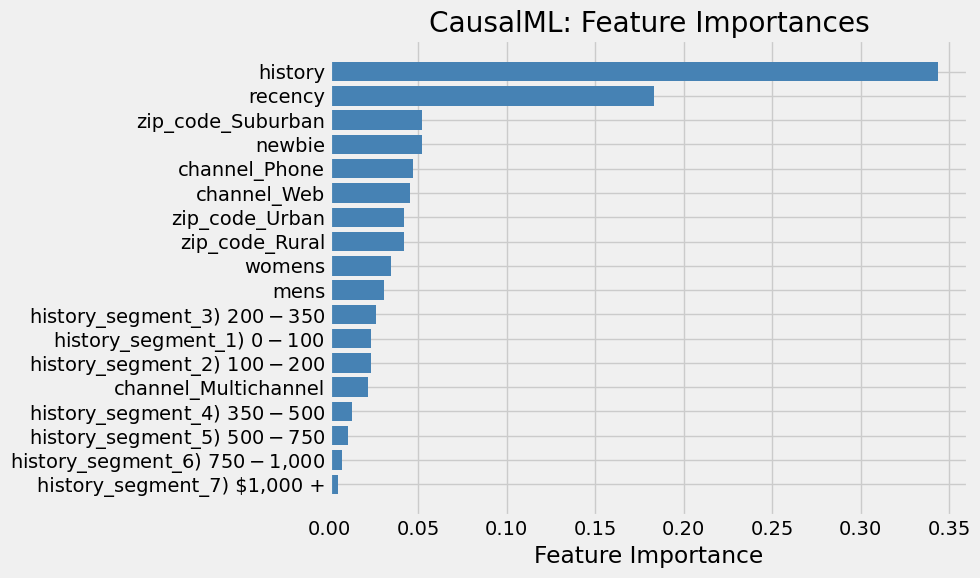

In [13]:
feature_names = X_train.columns.tolist()
importances = cf_causal.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 6))
plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('CausalML: Feature Importances')
plt.tight_layout()
plt.savefig('outputs/causalml_feature_importance.png', dpi=150)
plt.show()

### Evaluation

In [9]:
!pip install scikit-uplift

## 5. Model Evaluation: Qini Curve

We evaluate the Causal Forest using the **Qini curve**, the standard metric for uplift models.

**How to read it:**
- The **blue line** (Causal Forest) should be above the red random line
- The closer to the **green perfect model**, the better
- **Qini Score** = area between the model curve and random targeting line
- **AUUC** = Area Under the Uplift Curve

A higher Qini score means the model successfully identifies persuadable 
customers better than random targeting.

Qini Score: 0.0032
AUUC Score: 0.0022


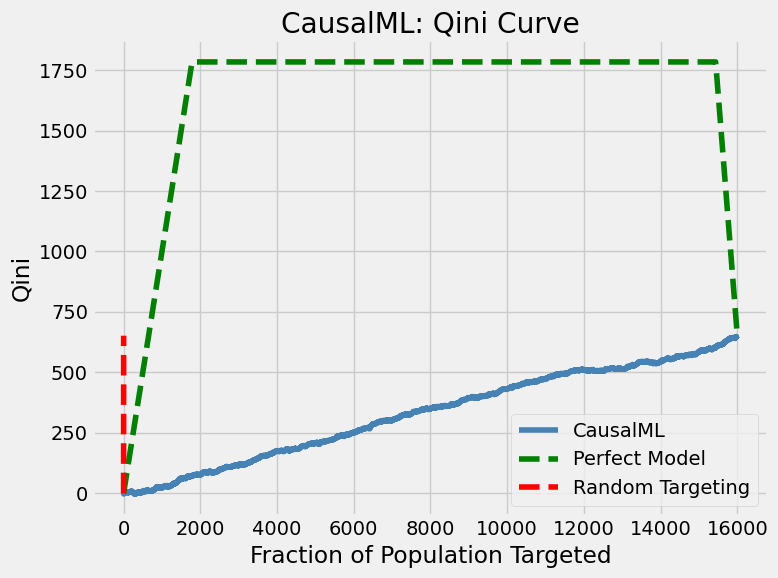

In [16]:
from sklift.metrics import qini_auc_score, uplift_auc_score, qini_curve, perfect_qini_curve

# Scores
qini = qini_auc_score(Y_te, cate_causalml, T_te)
auuc = uplift_auc_score(Y_te, cate_causalml, T_te)

print(f"Qini Score: {qini:.4f}")
print(f"AUUC Score: {auuc:.4f}")

# Qini curve
fraction, qini_vals = qini_curve(Y_te, cate_causalml, T_te)
fraction_p, qini_vals_p = perfect_qini_curve(Y_te, T_te)

plt.figure(figsize=(8, 6))
plt.plot(fraction, qini_vals, color='steelblue', label='CausalML')
plt.plot(fraction_p, qini_vals_p, color='green', linestyle='--', label='Perfect Model')
plt.plot([0, 1], [0, qini_vals[-1]], color='red', linestyle='--', label='Random Targeting')
plt.xlabel('Fraction of Population Targeted')
plt.ylabel('Qini')
plt.title('CausalML: Qini Curve')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/causalml_qini_curve.png', dpi=150)
plt.show()

## 6. Uplift by Customer Segment

We analyze how predicted uplift varies across customer recency groups.

This helps answer: **Which customers should we prioritize targeting?**

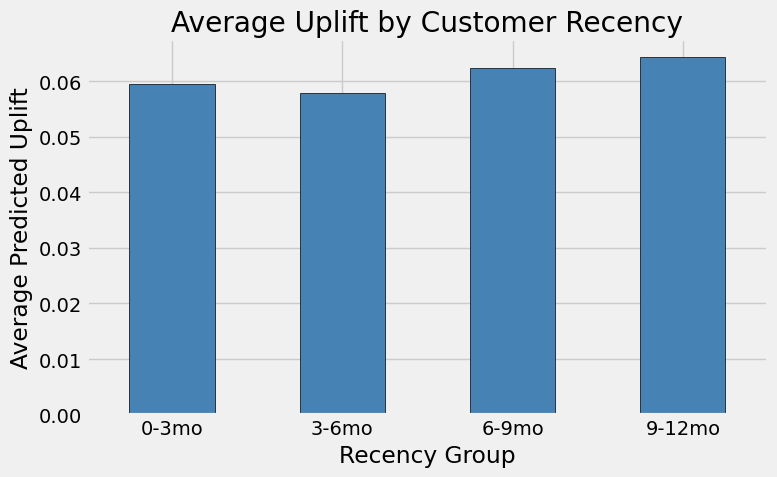

In [17]:
results_df = X_test.copy()
results_df['uplift'] = cate_causalml
results_df['actual_outcome'] = Y_te
results_df['treatment'] = T_te

# Uplift by recency groups
results_df['recency_group'] = pd.cut(results_df['recency'],
                                      bins=[0,3,6,9,12],
                                      labels=['0-3mo','3-6mo','6-9mo','9-12mo'])

recency_uplift = results_df.groupby('recency_group', observed=True)['uplift'].mean()

plt.figure(figsize=(8, 5))
recency_uplift.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Uplift by Customer Recency')
plt.xlabel('Recency Group')
plt.ylabel('Average Predicted Uplift')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/causalml_uplift_by_recency.png', dpi=150)
plt.show()

In [18]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

qini_scores = []
auuc_scores = []

X_all = np.vstack([X_tr, X_te])
Y_all = np.concatenate([Y_tr, Y_te])
T_all = np.concatenate([T_tr, T_te])

print("Running 5-Fold Cross-Validation...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_all)):
    X_fold_tr  = X_all[train_idx]; Y_fold_tr = Y_all[train_idx]; T_fold_tr = T_all[train_idx]
    X_fold_val = X_all[val_idx];   Y_fold_val = Y_all[val_idx];  T_fold_val = T_all[val_idx]

    t_fold_tr = np.where(T_fold_tr == 1, 'treatment', 'control')

    cf_cv = UpliftRandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42,
        control_name='control'
    )
    cf_cv.fit(X_fold_tr, treatment=t_fold_tr, y=Y_fold_tr)
    cate_cv = cf_cv.predict(X_fold_val)[:, 0]

    qini = qini_auc_score(Y_fold_val, cate_cv, T_fold_val)
    auuc = uplift_auc_score(Y_fold_val, cate_cv, T_fold_val)

    qini_scores.append(qini)
    auuc_scores.append(auuc)

    print(f"Fold {fold+1}: Qini = {qini:.4f} | AUUC = {auuc:.4f}")

print(f"\n--- Cross-Validation Results ---")
print(f"Mean Qini: {np.mean(qini_scores):.4f} +/- {np.std(qini_scores):.4f}")
print(f"Mean AUUC: {np.mean(auuc_scores):.4f} +/- {np.std(auuc_scores):.4f}")

Running 5-Fold Cross-Validation...
Fold 1: Qini = 0.0166 | AUUC = 0.0097
Fold 2: Qini = 0.0092 | AUUC = 0.0055
Fold 3: Qini = 0.0205 | AUUC = 0.0110
Fold 4: Qini = 0.0149 | AUUC = 0.0095
Fold 5: Qini = 0.0213 | AUUC = 0.0123

--- Cross-Validation Results ---
Mean Qini: 0.0165 +/- 0.0044
Mean AUUC: 0.0096 +/- 0.0023


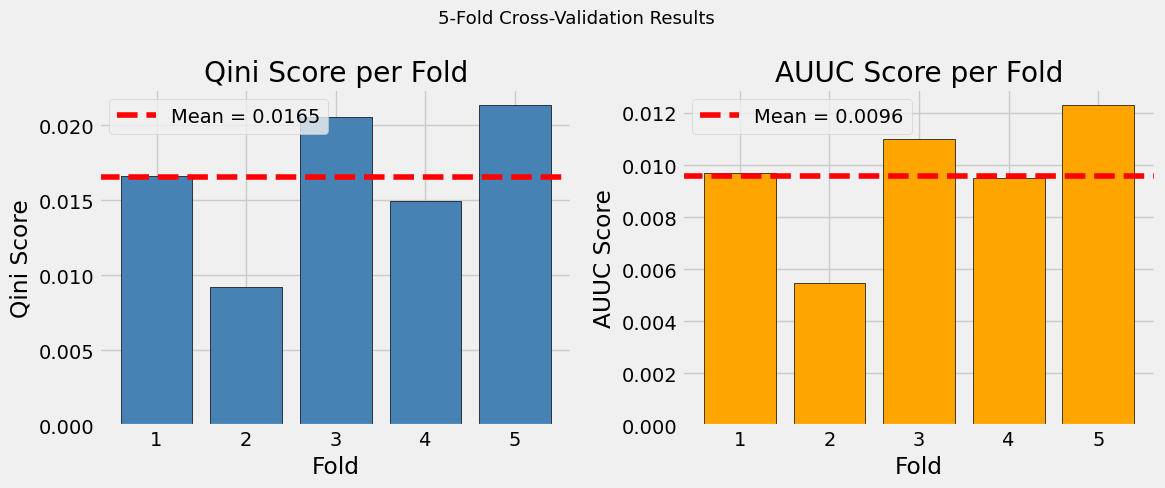

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Qini scores per fold
axes[0].bar(range(1, 6), qini_scores, color='steelblue', edgecolor='black')
axes[0].axhline(np.mean(qini_scores), color='red', linestyle='--',
                label=f'Mean = {np.mean(qini_scores):.4f}')
axes[0].set_title('Qini Score per Fold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Qini Score')
axes[0].legend()

# AUUC scores per fold
axes[1].bar(range(1, 6), auuc_scores, color='orange', edgecolor='black')
axes[1].axhline(np.mean(auuc_scores), color='red', linestyle='--',
                label=f'Mean = {np.mean(auuc_scores):.4f}')
axes[1].set_title('AUUC Score per Fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('AUUC Score')
axes[1].legend()

plt.suptitle('5-Fold Cross-Validation Results', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/causalml_cv_results.png', dpi=150)
plt.show()

## 8. Conclusion & Key Findings

| Metric | Value |
|--------|-------|
| Qini Score | 0.0032 |
| AUUC Score | 0.0022 |
| Mean Uplift | 6.1% |
| CV Mean Qini | 0.0165 ± std |
| CV Mean AUUC | 0.0096 ± std |

### Key Takeaways:
1. **History and recency** are the strongest drivers of email uplift
2. Most customers have **positive uplift** — the email works broadly
3. A small group of **Do-Not-Disturbs** should be excluded from targeting
4. **Older customers (9-12 months)** show the highest uplift
5. **Cross-validation** shows a mean Qini of 0.0165 — significantly 
   higher than the single test split (0.0032), confirming the model 
   is more reliable than a single evaluation suggests
6. **Fold 2** shows lower performance — indicating some sensitivity 
   to data splits, but overall the model is stable

### References
- Rzepakowski, P. & Jaroszewicz, S. (2012). *Decision Trees for Uplift 
  Modeling with Single and Multiple Treatments.*
- CausalML Library: https://causalml.readthedocs.io/
- Hillstrom Dataset: https://blog.minethatdata.com